                                                text  Cluster
0  http://www.edinburgh.gov.uk/images/SH_Barony.j...        3
1  http://www.edinburgh.gov.uk/images/SH_Bield.gi...        0
2  http://www.edinburgh.gov.uk/images/SH_Blackwoo...        3
3  http://www.edinburgh.gov.uk/images/SH_Cairn.gi...        1
4  http://www.edinburgh.gov.uk/images/SH_castlero...        2
5  http://www.edinburgh.gov.uk/images/SH_CEC.JPG ...        3
6  http://www.edinburgh.gov.uk/images/SH_Dunedin....        3
7  http://www.edinburgh.gov.uk/images/SH_hanoverl...        3
8  http://www.edinburgh.gov.uk/images/SH_Hillcres...        1
9  http://www.edinburgh.gov.uk/images/SH_Horizon....        3

Providers per cluster:
Cluster
0    2
1    3
2    1
3    9
Name: count, dtype: int64

Cluster 0: bield, leith, housing, port, 45am, care, 00pm, association, street, uk

Cluster 1: 30pm, hillcrest, cairn, 00am, 00pm, housing, 45pm, association, edinburgh, uk

Cluster 2: edinvar, castle, rock, castlerockedinvar, 657, 

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_3553/1496010758.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


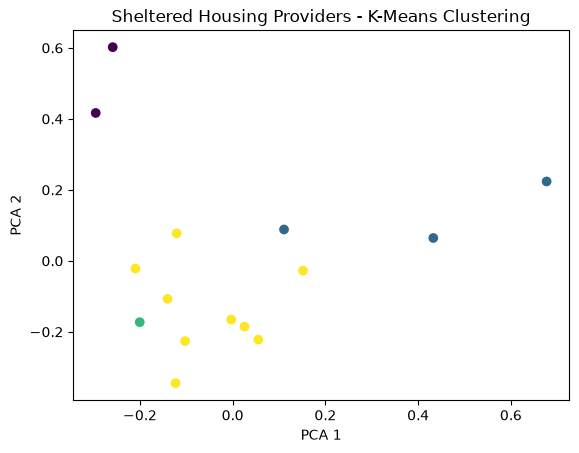

In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Load dataset
df = pd.read_csv("Sheltered Housing Providers.csv")

# 3. Clean missing values
df = df.fillna("")

# 4. Combine text columns
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].astype(str).agg(" ".join, axis=1)

# 5. NLP: TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=1000)
X = tfidf.fit_transform(df["text"])

# 6. K-Means clustering
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# 7. Show cluster results
print(df[["text", "Cluster"]].head(10))
print("\nProviders per cluster:")
print(df["Cluster"].value_counts().sort_index())

# 8. Show important words in each cluster
terms = tfidf.get_feature_names_out()

for i in range(k):
    words = [terms[j] for j in kmeans.cluster_centers_[i].argsort()[-10:][::-1]]
    print(f"\nCluster {i}: {', '.join(words)}")

# 9. Visualise clusters
X_pca = PCA(n_components=2).fit_transform(X.toarray())

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Sheltered Housing Providers - K-Means Clustering")
plt.show()

# 10. Save results
df.to_csv("Sheltered_Housing_Providers_Clustered.csv", index=False)